# Spacecraft Collision Avoidance

## 1. Imports

In [1]:
import json
import pickle
import re
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import plotly.express as px
import os
from ydata_profiling import ProfileReport
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

%matplotlib inline


C:\Users\edwin\AppData\Local\Temp\ipykernel_2168\434009212.py:10: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


## 2. Load data

In [2]:
df_train_raw = pd.read_csv('train_data.csv')
df_test_raw = pd.read_csv('test_data.csv')

#shape of the dataframes and number of unique events in each
print("Train DataFrame shape:", df_train_raw.shape, "| unique events:", df_train_raw['event_id'].nunique())
print("Test DataFrame shape:", df_test_raw.shape, "| unique events:", df_test_raw['event_id'].nunique())


Train DataFrame shape: (162634, 103) | unique events: 13154
Test DataFrame shape: (24484, 103) | unique events: 2167


In [3]:
#train and test time to close approach min and max
print(df_train_raw["time_to_tca"].describe().loc[["min","max"]])
print(df_test_raw["time_to_tca"].describe().loc[["min","max"]])

min   -0.149808
max    6.993832
Name: time_to_tca, dtype: float64
min    2.000213
max    6.993169
Name: time_to_tca, dtype: float64


In [5]:
# Precompute grouped counts once
event_counts = df_train_raw.groupby("event_id")["time_to_tca"]

# Count events with at least one CDM < 2 days
events_lt_2 = (event_counts.min() < 2).sum()

# Count events with at least one CDM > 2 days
events_gt_2 = (event_counts.max() > 2).sum()

# Total number of events
total_events = event_counts.size()

print("number of events that have < 2.0 days data :", events_lt_2)
print("number of events that have > 2.0 days data :", events_gt_2)
print("total number of events :",len(total_events))

# Lists of event_ids
events_less_than_two_days = event_counts.min()[event_counts.min() < 2].index.tolist()
events_more_than_two_days = event_counts.max()[event_counts.max() > 2].index.tolist()


number of events that have < 2.0 days data : 10104
number of events that have > 2.0 days data : 11942
total number of events : 13154


In [6]:
# Identify events that are present in both categories
events_trainable = [value for value in events_less_than_two_days if value in events_more_than_two_days]
print("number of trainable events : ",len(events_trainable))

number of trainable events :  8892


## 3. Build the dataset

For each event, per the challenge's three eligibility rules:

- **(i)** Only CDMs with `time_to_tca >= 2` may be used as inputs - this is the actual decision point (avoidance manoeuvres are planned at least 2 days out). We take the **most recent** such CDM per event as the feature row.
- **(ii)** The event's true final CDM (`time_to_tca` minimum overall) must be within 1 day of TCA - its `risk` is the prediction **target**, renamed `final_risk` so it's never confused with a row's own self-reported `risk`.
- **(iii)** The event needs at least one eligible (`>=2` days out) CDM to learn from, in addition to that final CDM as the target - i.e. **>= 2 CDMs total**, not >= 2 eligible CDMs.

 Overall, three constraints were put on events to be eligible in the test set

In [11]:
def build_event_level_dataset(df_raw, require_target=True):
    """Collapse a raw CDM-level dataframe into one row per eligible event.

    Parameters
    ----------
    df_raw : the raw per-CDM dataframe (e.g. df_train_raw or df_test_raw).
    require_target : True for files that still contain each event's true final CDM
        (e.g. the unfiltered train_data.csv), so a `final_risk` label can be derived
        locally. False for files that have had the near-TCA CDMs stripped out (e.g. the
        released test_data.csv) -- in that case you get features only; the ground truth
        for those events isn't present in the file and must come from elsewhere.
    """
    # Constraint (iii): only CDMs >= 2 days before TCA can be used as inputs
    eligible = df_raw[df_raw['time_to_tca'] >= 2]

    # Most recent eligible CDM per event = decision-point feature row
    latest_eligible_idx = eligible.groupby('event_id')['time_to_tca'].idxmin()
    latest_eligible = df_raw.loc[latest_eligible_idx].reset_index(drop=True)

    if not require_target:
        # e.g. test_data.csv: no CDM with time_to_tca < 2 exists in the file at all,
        # so there is nothing to derive a final_risk label from -- features only.
        return latest_eligible

    # Final CDM per event = the row with the smallest time_to_tca overall
    final_idx = df_raw.groupby('event_id')['time_to_tca'].idxmin()
    final_cdm = df_raw.loc[final_idx, ['event_id', 'time_to_tca', 'risk']].rename(
        columns={'time_to_tca': 'final_time_to_tca', 'risk': 'final_risk'}
    )

    events = final_cdm.set_index('event_id').join(
        latest_eligible.set_index('event_id'), how='inner'  # constraint (i): needs an eligible CDM too
    )

    # Constraint (ii): true final CDM must be within 1 day of TCA
    events = events[events['final_time_to_tca'] < 1]

    return events.reset_index()


challenge_train = build_event_level_dataset(df_train_raw, require_target=True)
challenge_test = build_event_level_dataset(df_test_raw, require_target=False)



print("Eligible train events:", len(challenge_train), "/", df_train_raw['event_id'].nunique())
print("Test events (features only, no local ground truth):", len(challenge_test),
      "/", df_test_raw['event_id'].nunique())

# Sanity checks
assert challenge_train['event_id'].is_unique
assert (challenge_train['time_to_tca'] >= 2).all()
assert (challenge_train['final_time_to_tca'] < 1).all()
assert challenge_test['event_id'].is_unique
assert (challenge_test['time_to_tca'] >= 2).all()
challenge_train.head()


Eligible train events: 8293 / 13154
Test events (features only, no local ground truth): 2167 / 2167


,event_id,final_time_to_tca,final_risk,time_to_tca,mission_id,risk,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,...,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP
0,2,0.401947,-30.000000,2.340627,2,-30.00000,-6.266241,401.442549,18763.0,14347.0,...,0.033330,3.039035,0.004753,0.053199,0.003115,0.194275,69.0,77.0,11.0,6.0
1,3,0.283061,-30.000000,2.278941,19,-30.00000,-7.320481,140.001151,23900.0,13574.0,...,0.095417,3.976678,0.008990,0.056902,0.007782,0.160887,68.0,70.0,0.0,7.0
2,4,0.273166,-27.650917,3.066467,19,-30.00000,-7.661743,434.669432,33593.0,12093.0,...,0.081852,2.058484,0.007439,0.054042,0.005327,0.076470,84.0,86.0,30.0,36.0
3,5,0.084142,-30.000000,2.103772,5,-13.10007,-4.878440,23.068536,304.0,2001.0,...,0.036157,0.037449,0.005818,0.005165,0.004303,0.004416,70.0,77.0,11.0,5.0
4,6,0.040905,-30.000000,2.040187,1,-30.00000,-5.079355,554.289715,10864.0,10027.0,...,0.036021,0.483927,0.001345,0.016114,0.004511,0.018473,72.0,70.0,14.0,4.0


In [13]:
print("Train DataFrame shape:", challenge_train.shape, "| unique events:", challenge_train['event_id'].nunique())

Train DataFrame shape: (8293, 105) | unique events: 8293


In [14]:
# Analyze risk distribution
high_risk_count = (challenge_train['final_risk'] >= -6.0).sum()
low_risk_count = (challenge_train['final_risk'] < -6.0).sum()
print("High risk:", high_risk_count)
print("Low risk:", low_risk_count)
print("Ratio:", (challenge_train['final_risk'] >= -6.0).sum() /(low_risk_count) * 100)

High risk: 66
Low risk: 8227
Ratio: 0.8022365382277865


In [15]:
# Uses the latest available risk value to determine the normal and anomalous cases
challenge_train['predicted_risk'] = 0 
challenge_train.loc[challenge_train['risk']<-6.0,'predicted_risk'] =  -6.000000000000001
challenge_train.loc[challenge_train['risk']>=-6.0,'predicted_risk'] =  challenge_train.loc[challenge_train['risk'] >=-6.0].risk.values

C:\Users\edwin\AppData\Local\Temp\ipykernel_2168\1635073534.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-6.000000000000001' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  challenge_train.loc[challenge_train['risk']<-6.0,'predicted_risk'] =  -6.000000000000001


In [16]:
# Assigns the classes based on risk values
challenge_train['predicted_risk_class']=np.nan
challenge_train.loc[challenge_train['predicted_risk']>=-6.0,'predicted_risk_class'] = int(1)
challenge_train.loc[challenge_train['predicted_risk']<-6.0,'predicted_risk_class'] = int(0)
print("number of high risk events with above criterion",challenge_train[challenge_train['predicted_risk_class']==1].shape[0])
print("number of low risk events with above criterion",challenge_train[challenge_train['predicted_risk_class']==0].shape[0])
print("ratio of high risk versus low risk with above criterion",challenge_train[challenge_train['predicted_risk_class']==1].shape[0]/challenge_train[challenge_train['predicted_risk_class']==0].shape[0]*100)

number of high risk events with above criterion 308
number of low risk events with above criterion 7985
ratio of high risk versus low risk with above criterion 3.857232310582342


In [17]:
challenge_train['predicted_risk_anomaly']=np.nan

challenge_train.loc[(challenge_train['predicted_risk']>=-6.0)&(challenge_train['final_risk']>=-6.0),'predicted_risk_anomaly'] = int(0) # both predicted and final risk are high risk
challenge_train.loc[(challenge_train['predicted_risk']<-6.0)&(challenge_train['final_risk']<-6.0),'predicted_risk_anomaly'] = int(1) # both predicted and final risk are low risk
challenge_train.loc[(challenge_train['predicted_risk']>=-6.0)&(challenge_train['final_risk']<-6.0),'predicted_risk_anomaly'] = int(2) # predicted high, final low
challenge_train.loc[(challenge_train['predicted_risk']<-6.0)&(challenge_train['final_risk']>=-6.0),'predicted_risk_anomaly'] = int(3) # predicted low, final high

print("number of 0 to 1 risk anomaly events with above criterion",challenge_train[challenge_train['predicted_risk_anomaly']==3].shape[0])
print("number of 1 to 0 risk anomaly events with above criterion",challenge_train[challenge_train['predicted_risk_anomaly']==2].shape[0])
print("number of 0 to 0 risk events with above criterion",challenge_train[challenge_train['predicted_risk_anomaly']==1].shape[0])
print("number of 1 to 1 risk events with above criterion",challenge_train[challenge_train['predicted_risk_anomaly']==0].shape[0])

number of 0 to 1 risk anomaly events with above criterion 19
number of 1 to 0 risk anomaly events with above criterion 261
number of 0 to 0 risk events with above criterion 7966
number of 1 to 1 risk events with above criterion 47


## 5. Missing values

In [19]:
# Calculate the percentage of missing values for each column
null_percentage = challenge_train.isnull().mean() * 100
complete_rows = challenge_train.dropna().shape[0]

print('Events with no missing values:', complete_rows, '/', challenge_train.shape[0])
print('Fraction of events with at least one missing value: '
      f"{1 - complete_rows / challenge_train.shape[0]:.2%}")
print('\nColumns with the most missing values:')
null_percentage.sort_values(ascending=False).head(10)

Events with no missing values: 4808 / 8293
Fraction of events with at least one missing value: 42.02%

Columns with the most missing values:


c_rcs_estimate    30.085614
t_ctdot_n         10.816351
t_crdot_r         10.816351
t_ctdot_t         10.816351
t_cndot_t         10.816351
t_cndot_n         10.816351
t_cndot_r         10.816351
t_ctdot_rdot      10.816351
t_ctdot_r         10.816351
t_crdot_n         10.816351
dtype: float64

## 6. (Optional) Full profiling report

Skip this cell if you just want the model — it's slow on large frames and is exploratory only.

In [44]:
profile = ProfileReport(challenge_train, minimal=True, explorative=False, title="Challenge Train Data Profile")
profile.to_file("train_data_profile.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 108/108 [00:01<00:00, 103.45it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 7. Feature selection

Numeric features from the decision-point CDM. `event_id` is excluded (a high-cardinality identifier, not a predictive feature - one-hot-encoding it would blow up into ~13k dummy columns and let the model memorize individual events). `risk` (the CDM's own self-reported risk at the decision point) is included as a feature - it's legitimately available at decision time, unlike `final_risk`.

**Leakage check:** `max_risk_estimate` / `max_risk_scaling` are themselves CDM-derived risk estimates, conceptually close to `risk`. Check the correlation printout below - if any single feature is near-perfectly correlated with `final_risk`, treat the result with suspicion and verify that feature is genuinely available (and genuinely different from a re-statement of the answer) at the >=2-day decision point.

In [20]:
# load or create your dataset
df_train = challenge_train.copy()

# Prepare features and target
X = df_train.drop(columns=["final_risk", "event_id", "mission_id", "final_time_to_tca"])
y = df_train["final_risk"]
X = pd.get_dummies(X, drop_first=True)
w = (y > 0.001).astype(int) * 10 + 1
X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(X, y, w, test_size=0.2, random_state=42)

# Create LightGBM datasets
train_data = lgb.Dataset(X_train, y_train, weight=w_train)
valid_data = lgb.Dataset(X_val, y_val, weight=w_val)

# specify your configurations as a dict
params = {
    "objective": "regression",
    "metric": "rmse",
    "num_leaves": 40,
    "learning_rate": 0.05,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
}
df_train.dtypes[df_train.dtypes == "object"]


model = lgb.train(
    params, 
    train_data, 
    num_boost_round=1000, 
    valid_sets=[train_data],
    valid_names=["validation"], 
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=50)]
)


# save model to file
model.save_model("model1.txt")

gain_importance = model.feature_importance(importance_type="gain")
split_importance = model.feature_importance(importance_type="split")
#print("Feature importance (gain): ", gain_importance)
#print("Feature importance (split): ", split_importance)

c:\Users\edwin\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightgbm\callback.py:347: UserWarning: Only training set found, disabling early stopping.
  _log_warning("Only training set found, disabling early stopping.")


[50]	validation's rmse: 3.5445
[100]	validation's rmse: 2.77437
[150]	validation's rmse: 2.27668
[200]	validation's rmse: 1.91212
[250]	validation's rmse: 1.63611
[300]	validation's rmse: 1.41404
[350]	validation's rmse: 1.23153
[400]	validation's rmse: 1.08501
[450]	validation's rmse: 0.955868
[500]	validation's rmse: 0.845847
[550]	validation's rmse: 0.751527
[600]	validation's rmse: 0.670424
[650]	validation's rmse: 0.600278
[700]	validation's rmse: 0.537896
[750]	validation's rmse: 0.486191
[800]	validation's rmse: 0.438313
[850]	validation's rmse: 0.398048
[900]	validation's rmse: 0.363278
[950]	validation's rmse: 0.331682
[1000]	validation's rmse: 0.302534


In [24]:
# manually selected top features based on correlation and feature importance
top_features = ["relative_position_r",
    "relative_velocity_t",
    "mahalanobis_distance",
    "c_position_covariance_det",
    "c_sigma_t",
    "t_span",
    "t_rcs_estimate",
    "miss_distance",
    "risk",
    "max_risk_estimate",
    "max_risk_scaling"
]

## 8. Train / validation split


In [ ]:
X = challenge_train[top_features]
TARGET = "final_risk"
y = challenge_train[TARGET]
RISK_THRESHOLD = -6
high_risk_label = (y >= RISK_THRESHOLD).astype(int)  # Create a binary label for high-risk events
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=high_risk_label
)

# Upweight higher-risk events so the (rare) dangerous ones aren't drowned out by the many
# low-risk ones. Threshold/weight are a starting point — worth a sensitivity check later.

HIGH_RISK_WEIGHT = 190

w_train = (y_train >= RISK_THRESHOLD).astype(int) * HIGH_RISK_WEIGHT + 1
w_valid = (y_valid >= RISK_THRESHOLD).astype(int) * HIGH_RISK_WEIGHT + 1

train_data = lgb.Dataset(X_train, label=y_train, weight=w_train, free_raw_data=False)
valid_data = lgb.Dataset(X_valid, label=y_valid, weight=w_valid, reference=train_data, free_raw_data=False)


In [26]:
train_high_risk = (y_train >= RISK_THRESHOLD).mean()
valid_high_risk = (y_valid >= RISK_THRESHOLD).mean()

print(f"Train size: {len(y_train)}")
print(f"Validation size: {len(y_valid)}")
print(f"Train high-risk proportion: {train_high_risk:.3%}")
print(f"Validation high-risk proportion: {valid_high_risk:.3%}")

Train size: 6634
Validation size: 1659
Train high-risk proportion: 0.799%
Validation high-risk proportion: 0.784%


## 9. Train the model

In [27]:
params = {
    "objective": "regression",
    "metric": "rmse",
    "num_leaves": 31,
    "learning_rate": 0.05,
    "feature_fraction": 1.0,  # already hand-selected the features
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=900,
    valid_sets=[train_data, valid_data],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(stopping_rounds=50)],
)

print("Finished training. Best iteration:", model.best_iteration)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[22]	train's rmse: 5.2862	valid's rmse: 9.16299
Finished training. Best iteration: 22


In [28]:
# Evaluate on validation set
y_valid_pred = model.predict(X_valid, num_iteration=model.best_iteration)
baseline_risk_valid = challenge_train.loc[X_valid.index, "risk"].values
y_valid_pred_blended = np.maximum(y_valid_pred, baseline_risk_valid)
weighted_valid_rmse = np.sqrt(np.average((y_valid - y_valid_pred_blended) ** 2,weights=w_valid))

unweighted_valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred_blended))

print("Weighted validation RMSE:", weighted_valid_rmse)
print("Unweighted validation RMSE:", unweighted_valid_rmse)


Weighted validation RMSE: 6.896418458065473
Unweighted validation RMSE: 10.385386514144194


## 10. Save the model

In [29]:
model.save_model("model.txt")

with open("model.json", "w") as f:
    json.dump(model.dump_model(), f, indent=4)

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved")


Model saved


## 11. Generate predictions on the test set

In [30]:
# Generate predictions for the test set
X_test = challenge_test[top_features]
y_test_pred = model.predict(X_test, num_iteration=model.best_iteration)
y_test_pred_blended = np.maximum(y_test_pred, challenge_test["risk"].values)
# Save predictions to CSV
test_predictions = challenge_test[['event_id']].copy()
test_predictions['final_risk_predicted'] = y_test_pred_blended
test_predictions.to_csv("test_predictions.csv", index=False)
print("Saved predictions to test_predictions.csv")
test_predictions.sort_values("final_risk_predicted", ascending=False).head(20)


Saved predictions to test_predictions.csv


,event_id,final_risk_predicted
891,891,-2.892112
1568,1568,-2.987585
1448,1448,-3.041102
2059,2059,-3.103860
2091,2091,-3.141282
1259,1259,-3.155647
1984,1984,-3.212044
1792,1792,-3.383210
868,868,-3.511731
2117,2117,-3.519849


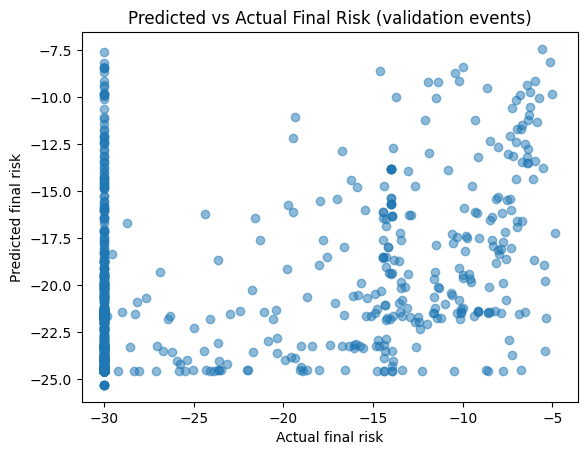

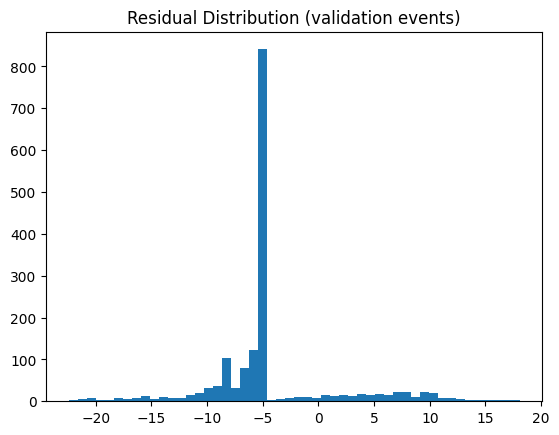

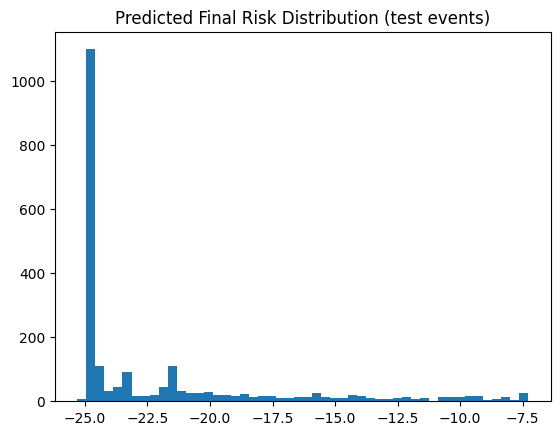

In [31]:
# Diagnostic plots against the VALIDATION split (the only place we have true final_risk
plt.scatter(y_valid, y_valid_pred, alpha=0.5)
plt.xlabel("Actual final risk")
plt.ylabel("Predicted final risk")
plt.title("Predicted vs Actual Final Risk (validation events)")
plt.show()

residuals = y_valid - y_valid_pred
plt.hist(residuals, bins=50)
plt.title("Residual Distribution (validation events)")
plt.show()

# Distribution of predicted risk on the actual test events
plt.hist(y_test_pred, bins=50)
plt.title("Predicted Final Risk Distribution (test events)")
plt.show()


In [32]:

# 1. LightGBM predictions — RAW
y_valid_pred_lgbm = model.predict(
    X_valid,
    num_iteration=model.best_iteration
)

# 2. ESA LRP baseline
# Latest available risk is the prediction
baseline_risk = challenge_train.loc[X_valid.index, "risk"].values

y_valid_pred_baseline = np.where(
    baseline_risk >= -6.0,
    baseline_risk,
    -6.0
)

# 3. Overall RMSE
baseline_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred_baseline))
lgbm_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred_lgbm))

print("RMSE comparison")
print("----------------------------")
print(f"ESA baseline RMSE: {baseline_rmse:.6f}")
print(f"LightGBM RMSE:     {lgbm_rmse:.6f}")


# 4. Define high-risk events (matches the official r >= 10^-6 cutoff, on a log10 scale -> -6.0)

HIGH_RISK_THRESHOLD = -6.0

actual_high_risk = y_valid >= HIGH_RISK_THRESHOLD

print("\nHigh-risk validation events:", actual_high_risk.sum())
print("Total validation events:", len(y_valid))
print("High-risk proportion:", f"{actual_high_risk.mean():.2%}")


# 5. High-risk MSE
baseline_mse_hr = np.mean((y_valid[actual_high_risk] - y_valid_pred_baseline[actual_high_risk]) ** 2)
lgbm_mse_hr = np.mean((y_valid[actual_high_risk] - y_valid_pred_lgbm[actual_high_risk]) ** 2)

print("\nHigh-risk MSE")
print("----------------------------")
print(f"ESA baseline MSE_HR: {baseline_mse_hr:.6f}")
print(f"LightGBM MSE_HR:     {lgbm_mse_hr:.6f}")


# 6. F2 score (matches the official scoring: computed over the whole set, both classes)

def calculate_f2_score(y_true, y_pred, threshold=-6.0):
    actual_high = np.asarray(y_true) >= threshold
    predicted_high = np.asarray(y_pred) >= threshold

    true_positive = np.sum(actual_high & predicted_high)
    false_positive = np.sum(~actual_high & predicted_high)
    false_negative = np.sum(actual_high & ~predicted_high)

    precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0.0
    recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0.0

    beta = 2.0
    f2 = (
        (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall)
        if ((beta**2 * precision) + recall) > 0
        else 0.0
    )
    return f2, precision, recall

baseline_f2, baseline_precision, baseline_recall = calculate_f2_score(y_valid, y_valid_pred_baseline, HIGH_RISK_THRESHOLD)
lgbm_f2, lgbm_precision, lgbm_recall = calculate_f2_score(y_valid, y_valid_pred_lgbm, HIGH_RISK_THRESHOLD)

print("\nHigh-risk classification")
print("----------------------------")
print(f"ESA baseline F2:        {baseline_f2:.6f}")
print(f"ESA baseline Precision: {baseline_precision:.6f}")
print(f"ESA baseline Recall:    {baseline_recall:.6f}")
print()
print(f"LightGBM F2:            {lgbm_f2:.6f}")
print(f"LightGBM Precision:     {lgbm_precision:.6f}")
print(f"LightGBM Recall:        {lgbm_recall:.6f}")


# 7. Competition-style loss  L = MSE_HR / F2 

baseline_loss = baseline_mse_hr / baseline_f2 if baseline_f2 > 0 else np.inf
lgbm_loss = lgbm_mse_hr / lgbm_f2 if lgbm_f2 > 0 else np.inf

print("\nCompetition-style loss")
print("----------------------------")
print(f"ESA baseline L: {baseline_loss:.6f}")
print(f"LightGBM L:     {lgbm_loss:.6f}")


# 8. Final comparison table

comparison = pd.DataFrame({
    "Model": ["ESA notebook baseline", "LightGBM "],
    "RMSE": [baseline_rmse, lgbm_rmse],
    "High-Risk MSE": [baseline_mse_hr, lgbm_mse_hr],
    "F2": [baseline_f2, lgbm_f2],
    "Precision": [baseline_precision, lgbm_precision],
    "Recall": [baseline_recall, lgbm_recall],
    "Competition Loss": [baseline_loss, lgbm_loss],
})

print("\nFinal comparison")
print("----------------------------")
print(comparison.to_string(index=False))


RMSE comparison
----------------------------
ESA baseline RMSE: 22.074041
LightGBM RMSE:     7.375575

High-risk validation events: 13
Total validation events: 1659
High-risk proportion: 0.78%

High-risk MSE
----------------------------
ESA baseline MSE_HR: 0.401433
LightGBM MSE_HR:     103.815611

High-risk classification
----------------------------
ESA baseline F2:        0.037989
ESA baseline Precision: 0.007836
ESA baseline Recall:    1.000000

LightGBM F2:            0.000000
LightGBM Precision:     0.000000
LightGBM Recall:        0.000000

Competition-style loss
----------------------------
ESA baseline L: 10.566964
LightGBM L:     inf

Final comparison
----------------------------
                Model      RMSE  High-Risk MSE       F2  Precision  Recall  Competition Loss
ESA notebook baseline 22.074041       0.401433 0.037989   0.007836     1.0         10.566964
            LightGBM   7.375575     103.815611 0.000000   0.000000     0.0               inf


In [33]:
diagnostic = pd.DataFrame({
    "actual": y_valid.values,
    "risk_input": X_valid["risk"].values,
    "ESA_baseline": y_valid_pred_baseline,
    "LightGBM": y_valid_pred_lgbm
})

print(diagnostic.head(20))

print("\nBaseline == risk:")
print(np.allclose(
    diagnostic["ESA_baseline"],
    diagnostic["risk_input"]
))

print("\nLightGBM == risk:")
print(np.allclose(
    diagnostic["LightGBM"],
    diagnostic["risk_input"]
))

print("\nBaseline == LightGBM:")
print(np.allclose(
    diagnostic["ESA_baseline"],
    diagnostic["LightGBM"]
))

       actual  risk_input  ESA_baseline   LightGBM
0  -17.422623  -17.336865          -6.0 -23.185431
1  -13.396314  -23.943476          -6.0 -24.512863
2  -30.000000  -30.000000          -6.0 -24.582877
3  -30.000000  -30.000000          -6.0 -24.582877
4  -30.000000   -7.027751          -6.0 -20.146180
5   -5.982967   -6.017774          -6.0 -13.400954
6  -30.000000  -14.546835          -6.0 -20.419063
7  -30.000000  -30.000000          -6.0 -24.582877
8  -30.000000   -7.703993          -6.0 -21.500100
9  -30.000000   -7.150335          -6.0 -20.146180
10 -13.971429  -30.000000          -6.0 -15.368310
11 -30.000000  -30.000000          -6.0 -24.582877
12 -30.000000  -30.000000          -6.0 -24.582877
13 -30.000000  -30.000000          -6.0 -24.582877
14 -30.000000  -30.000000          -6.0 -24.582877
15 -30.000000  -30.000000          -6.0 -24.582877
16 -30.000000  -30.000000          -6.0 -24.582877
17 -30.000000  -27.605548          -6.0 -23.901979
18 -30.000000  -18.184090      

In [34]:

# Inspect the actual high-risk validation events

high_risk_validation = pd.DataFrame({
    "actual_final_risk": y_valid,
    "ESA_baseline_prediction": y_valid_pred_baseline,
    "LightGBM_prediction": y_valid_pred_lgbm,
})

high_risk_validation = high_risk_validation[
    high_risk_validation["actual_final_risk"] >= HIGH_RISK_THRESHOLD
].sort_values("actual_final_risk", ascending=False)

print(high_risk_validation)


      actual_final_risk  ESA_baseline_prediction  LightGBM_prediction
5482          -4.843451                -6.000000           -17.232087
113           -5.019997                -4.937042            -9.795895
4227          -5.125286                -5.118501            -8.135326
6205          -5.366128                -6.000000           -21.727958
7033          -5.428990                -5.486782           -23.486633
152           -5.432268                -5.013676           -19.784134
6082          -5.483994                -6.000000           -18.903968
8043          -5.525201                -5.667966           -13.782973
5600          -5.600153                -4.022551            -7.419892
5622          -5.767512                -5.066108           -10.014239
8186          -5.838932                -6.000000           -11.328356
5562          -5.982967                -6.000000           -13.400954
2267          -5.991400                -6.000000            -9.105586


In [35]:
print("\nHighest LightGBM predictions:")
print(
    high_risk_validation
    .sort_values("LightGBM_prediction", ascending=False)
)


Highest LightGBM predictions:
      actual_final_risk  ESA_baseline_prediction  LightGBM_prediction
5600          -5.600153                -4.022551            -7.419892
4227          -5.125286                -5.118501            -8.135326
2267          -5.991400                -6.000000            -9.105586
113           -5.019997                -4.937042            -9.795895
5622          -5.767512                -5.066108           -10.014239
8186          -5.838932                -6.000000           -11.328356
5562          -5.982967                -6.000000           -13.400954
8043          -5.525201                -5.667966           -13.782973
5482          -4.843451                -6.000000           -17.232087
6082          -5.483994                -6.000000           -18.903968
152           -5.432268                -5.013676           -19.784134
6205          -5.366128                -6.000000           -21.727958
7033          -5.428990                -5.486782           

## 12. Feature importance

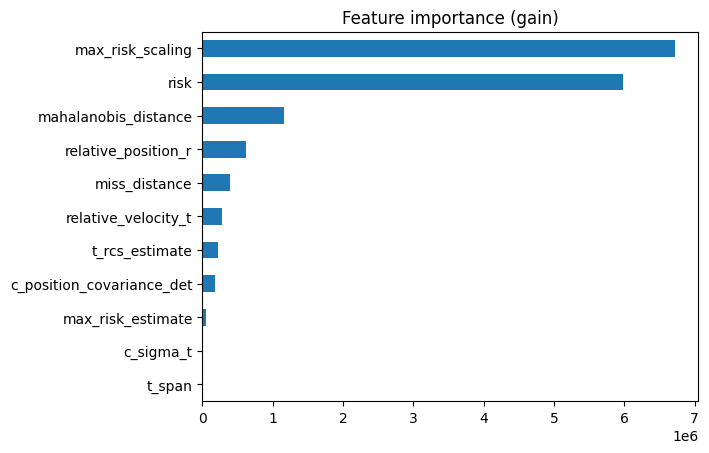

In [36]:
importance = pd.Series(
    model.feature_importance(importance_type="gain"), index=top_features
).sort_values(ascending=False)

importance.plot.barh(title="Feature importance (gain)")
plt.gca().invert_yaxis()
plt.show()


In [37]:
final_pred = np.maximum(y_valid_pred_lgbm, challenge_train.loc[X_valid.index, "risk"])
print(final_pred)

3003   -17.336865
704    -23.943476
3500   -24.582877
3208   -24.582877
766     -7.027751
          ...    
4421   -23.686138
6568    -8.366734
1259   -14.295592
5069   -24.582877
2714   -24.582877
Name: risk, Length: 1659, dtype: float64


In [38]:
print(np.array_equal(y_valid_pred_baseline, y_valid_pred_lgbm))
print(np.max(np.abs(y_valid_pred_baseline - y_valid_pred_lgbm)))

False
19.301692048829263
